# 🚀 Agentic RAG Walkthrough

This notebook demonstrates how to build an **Agentic Retrieval-Augmented Generation (RAG)** workflow step by step.  
In a traditional RAG system, the model always retrieves documents before answering.
In an **Agentic** RAG, the model (acting as an agent) can decide whether it needs to retrieve information or can answer directly.
This workflow also includes steps to grade the relevance of retrieved documents and rewrite the query if needed.

We will:
1. Install and set up libraries.  
2. Load and split documents.  
3. Create a retriever tool for semantic search.  
4. Let the model decide when to search or answer directly.  
5. Grade and improve retrieved answers.  
6. Generate the final response.  
7. Build a small workflow graph to connect everything.  
8. Run the workflow on a sample question.  

#Install Dependencies and Set Up API Key

Install required Python packages for building the RAG system.
- **langgraph** is used for creating the workflow graph.
- **langchain[openai]** provides core LangChain functionality and OpenAI integrations.
- **langchain-community** includes community-contributed modules like document loaders.
- **langchain-text-splitters** provides
utilities for splitting text into chunks.




In [ ]:
# Install dependencies
!pip install -U --quiet langgraph "langchain[openai]" langchain-community langchain-text-splitters

Before we can interact with OpenAI models or use LangChain components, we need to securely provide our API key.
The following cell prompts you to enter your key and sets it as an environment variable.
This is a secure way to handle API keys without hardcoding them into the notebook.


In [ ]:
import getpass
import os


def _set_env(key: str):
  """Helper function to set an environment variable if it's not already set.
    Prompts the user to input the value securely."""
    if key not in os.environ:
        os.environ[key] = getpass.getpass(f"{key}:")


_set_env("OPENAI_API_KEY")

OPENAI_API_KEY:··········


## **1. Preprocess Documents**

- We start by **loading documents from the web**. This will serve as our knowledge base.
- `WebBaseLoader` fetches content from the specified URL and returns it as document objects.  
- This is the raw text we will later process for retrieval.


In [ ]:
from langchain_community.document_loaders import WebBaseLoader

# Define a list of URLs to load blog posts from Lilian Weng's website.
urls = [
    "https://lilianweng.github.io/posts/2024-11-28-reward-hacking/",
    "https://lilianweng.github.io/posts/2024-07-07-hallucination/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/",
]

# Load documents from each URL. The result is a list of lists, so we flatten it.
docs = [WebBaseLoader(url).load() for url in urls]

In [ ]:
# Display the first 1000 characters of the first document to see what we've loaded.
docs[0][0].page_content.strip()[:1000]

"Reward Hacking in Reinforcement Learning | Lil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ\n\n\n\n\n\n\n\n\n\n      Reward Hacking in Reinforcement Learning\n    \nDate: November 28, 2024  |  Estimated Reading Time: 37 min  |  Author: Lilian Weng\n\n\n \n\n\nTable of Contents\n\n\n\nBackground\n\nReward Function in RL\n\nSpurious Correlation\n\n\nLet’s Define Reward Hacking\n\nList of Examples\n\nReward hacking examples in RL tasks\n\nReward hacking examples in LLM tasks\n\nReward hacking examples in real life\n\n\nWhy does Reward Hacking Exist?\n\n\nHacking RL Environment\n\nHacking RLHF of LLMs\n\nHacking the Training Process\n\nHacking the Evaluator\n\nIn-Context Reward Hacking\n\n\nGeneralization of Hacking Skills\n\nPeek into Mitigations\n\nRL Algorithm Improvement\n\nDetecting Reward Hacking\n\nData Analysis of RLHF\

- To make these documents easier to search, we must split them into smaller, manageable chunks.
- Large documents are hard for retrieval systems to handle effectively.
- `RecursiveCharacterTextSplitter` splits text recursively by different characters (e.g., paragraphs, sentences, words)
- until chunks are small enough. `chunk_size` and `chunk_overlap` control the size and overlap of chunks.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Flatten the list of document lists into a single list of documents.
docs_list = [item for sublist in docs for item in sublist]

# Initialize the text splitter. We use the TikToken encoder (used by OpenAI models) to count tokens accurately.
# Chunk size is 100 tokens, with 50 tokens of overlap to maintain context between chunks.
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=100, chunk_overlap=50
)

# Split all documents into smaller chunks.
doc_splits = text_splitter.split_documents(docs_list)

In [ ]:
# Display the content of the first chunk to see the result.
doc_splits[0].page_content.strip()

"Reward Hacking in Reinforcement Learning | Lil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nLil'Log\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n|\n\n\n\n\n\n\nPosts\n\n\n\n\nArchive\n\n\n\n\nSearch\n\n\n\n\nTags\n\n\n\n\nFAQ"

## **2. Create a Retriever Tool**

- Now we **convert the document chunks into vector embeddings** and store them in memory.  
- Vector embeddings are numerical representations of text that capture semantic meaning.
- The retriever will use these embeddings to perform semantic searches (finding text that is **similar in meaning**).



In [ ]:
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings

# Create an in-memory vector store from the document chunks using OpenAI's embedding model.
vectorstore = InMemoryVectorStore.from_documents(
    documents=doc_splits, embedding=OpenAIEmbeddings()
)

# Create a retriever object from the vector store. This object can search for relevant documents.
retriever = vectorstore.as_retriever()

We then **wrap the retriever as a tool** using `create_retriever_tool`.  
This allows an agent (our LLM) to call the retriever whenever it needs to fetch relevant information.
Think of a tool as a function the LLM can choose to use.


In [ ]:
from langchain.tools.retriever import create_retriever_tool

retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_blog_posts", # The name of the tool. The LLM will refer to it by this name.
    "Search and return information about Lilian Weng blog posts.", # A description to help the LLM understand when to use it.
)

In [ ]:
# Test the retriever tool by invoking it with a sample query.
# This confirms our retriever tool is working as intended and can find relevant text chunks.
retriever_tool.invoke({"query": "types of reward hacking"})

'Detecting Reward Hacking#\n\nIn-Context Reward Hacking#\n\n(Note: Some work defines reward tampering as a distinct category of misalignment behavior from reward hacking. But I consider reward hacking as a broader concept here.)\nAt a high level, reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering.\n\nWhy does Reward Hacking Exist?#'

## **3. Generate Query**

For structured agent workflows, messages need a consistent format.
`MessagesState` is a predefined state schema in LangGraph that expects a list of messages.
We create a function that will be a node in our workflow graph. This node uses the LLM to decide what to do next.

In [ ]:
from langgraph.graph import MessagesState
from langchain.chat_models import init_chat_model

# Initialize the chat model we will use. We use GPT-4 with temperature=0 for deterministic, focused responses.
response_model = init_chat_model("openai:gpt-4.1", temperature=0)


def generate_query_or_respond(state: MessagesState):
    """Call the model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply respond to the user.
    """
    # Bind the retriever tool to the model. This tells the model it has this tool available.
    # The model will output a function call if it decides to use the tool.
    response = (
        response_model
        .bind_tools([retriever_tool]).invoke(state["messages"])
    )
    return {"messages": [response]}

In [ ]:
# Test the function with a simple greeting. The model should respond directly.
input = {"messages": [{"role": "user", "content": "hello!"}]}
generate_query_or_respond(input)["messages"][-1].pretty_print()

================================== Ai Message ==================================

Hello! How can I help you today?


In [ ]:
#Test the function with a question that likely requires retrieval.
# The model should decide to call the 'retrieve_blog_posts' tool.
input = {
    "messages": [
        {
            "role": "user",
            "content": "What does Lilian Weng say about types of reward hacking?",
        }
    ]
}
generate_query_or_respond(input)["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (call_rWzhSEGW4UHjEtjQK4ijkCU2)
 Call ID: call_rWzhSEGW4UHjEtjQK4ijkCU2
  Args:
    query: types of reward hacking


## **4. Grade Documents**

After retrieving documents, we need to check if they are actually relevant to the user's question.
This step prevents the model from generating an answer based on poor or irrelevant context.
We define a Pydantic model to structure the grader's output and a prompt to guide the LLM.

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal

# Define the prompt for the grader. It instructs the LLM to assess relevance.
GRADE_PROMPT = (
    "You are a grader assessing relevance of a retrieved document to a user question. \n "
    "Here is the retrieved document: \n\n {context} \n\n"
    "Here is the user question: {question} \n"
    "If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n"
    "Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."
)

# Define the output schema for the grader using Pydantic.
# This ensures the LLM returns a predictable, structured response.
class GradeDocuments(BaseModel):
    """Grade documents using a binary score for relevance check."""

    binary_score: str = Field(
        description="Relevance score: 'yes' if relevant, or 'no' if not relevant"
    )

# Initialize the grader model
grader_model = init_chat_model("openai:gpt-4.1", temperature=0)


def grade_documents(
    state: MessagesState,
) -> Literal["generate_answer", "rewrite_question"]:
    """Determine whether the retrieved documents are relevant to the question."""
    question = state["messages"][0].content
    context = state["messages"][-1].content

    # Format the prompt with the actual question and context.
    prompt = GRADE_PROMPT.format(question=question, context=context)
    # Call the grader model with the structured output schema.
    response = (
        grader_model
        .with_structured_output(GradeDocuments).invoke(
            [{"role": "user", "content": prompt}]
        )
    )
    # Return the next node name based on the binary score.
    score = response.binary_score

    if score == "yes":
        return "generate_answer"
    else:
        return "rewrite_question"

In [ ]:
# Import utility for converting dictionaries to proper LangChain message objects.
from langchain_core.messages import convert_to_messages

# Test the grader with irrelevant context ("meow"). It should return 'rewrite_question'.
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {"role": "tool", "content": "meow", "tool_call_id": "1"},
        ]
    )
}
grade_documents(input)

'rewrite_question'

In [ ]:
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {
                "role": "tool",
                "content": "reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering",
                "tool_call_id": "1",
            },
        ]
    )
}
grade_documents(input)

'rewrite_question'

## **5. Rewrite Question**

If the retrieved documents are not relevant, we rewrite the user's question.
The goal is to reformulate the query to better capture the underlying intent, which might yield better results on a second try.


In [ ]:
REWRITE_PROMPT = (
    "Look at the input and try to reason about the underlying semantic intent / meaning.\n"
    "Here is the initial question:"
    "\n ------- \n"
    "{question}"
    "\n ------- \n"
    "Formulate an improved question:"
)


def rewrite_question(state: MessagesState):
    """Rewrite the original user question."""
    messages = state["messages"]
    question = messages[0].content
    prompt = REWRITE_PROMPT.format(question=question)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [{"role": "user", "content": response.content}]}

In [ ]:
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {"role": "tool", "content": "meow", "tool_call_id": "1"},
        ]
    )
}

response = rewrite_question(input)
print(response["messages"][-1]["content"])

Improved question:  
What are the different types of reward hacking described by Lilian Weng, and how does she explain them?


## **6. Generate an answer**

Once we have relevant context, this function generates the final answer for the user.
It provides the context and the question to the LLM and asks it to formulate a concise response.


In [ ]:
GENERATE_PROMPT = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, just say that you don't know. "
    "Use three sentences maximum and keep the answer concise.\n"
    "Question: {question} \n"
    "Context: {context}"
)


def generate_answer(state: MessagesState):
    """Generate an answer."""
    question = state["messages"][0].content
    context = state["messages"][-1].content
    prompt = GENERATE_PROMPT.format(question=question, context=context)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [response]}

In [ ]:
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {"query": "types of reward hacking"},
                    }
                ],
            },
            {
                "role": "tool",
                "content": "reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering",
                "tool_call_id": "1",
            },
        ]
    )
}

response = generate_answer(input)
response["messages"][-1].pretty_print()

================================== Ai Message ==================================

Lilian Weng says that reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering. Environment or goal misspecification occurs when the designed reward does not align with the intended goal. Reward tampering involves the agent manipulating the reward signal itself.


## **7. Assemble The Graph**

Now we assemble all the pieces into a single workflow using LangGraph.
A graph defines the sequence of steps (nodes) and the conditions for moving between them (edges).


In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Initialize the state graph with the MessagesState schema.
workflow = StateGraph(MessagesState)

# Define the nodes we will cycle between
workflow.add_node(generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retriever_tool]))
workflow.add_node(rewrite_question)
workflow.add_node(generate_answer)

workflow.add_edge(START, "generate_query_or_respond")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "generate_query_or_respond",
    # Assess LLM decision (call `retriever_tool` tool or respond to the user)
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate_answer", END)
workflow.add_edge("rewrite_question", "generate_query_or_respond")

# Compile
graph = workflow.compile()

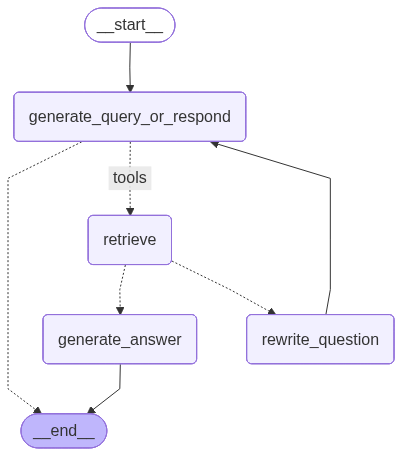

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## **8. Run The Agentic RAG**

Finally, we run the entire workflow on a sample question.
The `stream` method executes the graph step-by-step and yields updates from each node.
This allows us to see the intermediate steps (e.g., the tool call, the retrieved context, the final answer).


In [ ]:
for chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "What does Lilian Weng say about types of reward hacking?",
            }
        ]
    }
):
    for node, update in chunk.items():
        print("Update from node", node)
        update["messages"][-1].pretty_print()
        print("\n\n")

Update from node generate_query_or_respond
================================== Ai Message ==================================
Tool Calls:
  retrieve_blog_posts (call_MPRpekF3zUnyBlqZOh7v2CvK)
 Call ID: call_MPRpekF3zUnyBlqZOh7v2CvK
  Args:
    query: types of reward hacking



Update from node retrieve
================================= Tool Message =================================
Name: retrieve_blog_posts

Detecting Reward Hacking#

In-Context Reward Hacking#

(Note: Some work defines reward tampering as a distinct category of misalignment behavior from reward hacking. But I consider reward hacking as a broader concept here.)
At a high level, reward hacking can be categorized into two types: environment or goal misspecification, and reward tampering.

Why does Reward Hacking Exist?#



Update from node generate_answer
================================== Ai Message ==================================

Lilian Weng categorizes reward hacking into two types: environment or goal misspecificat

##Conclusion
This notebook has demonstrated how to build an **Agentic RAG** system, a significant advancement over standard RAG.

While standard RAG simply retrieves and generates, Agentic RAG introduces **autonomous decision-making**. The agent intelligently chooses when to retrieve, critically evaluates the quality of the information it finds, and can even refine its own search strategy.

This results in a more efficient, robust, and reliable system. It avoids unnecessary searches for simple queries and actively works to find better information when initial results are poor, closely mimicking how a skilled human researcher operates.

By combining the vast knowledge of LLMs with the precision of retrieval and the intelligence of agentic workflows, Agentic RAG represents a powerful paradigm for building trustworthy and capable AI applications.